<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB
None
               ID#       Balance    Qual_miles    cc1_miles    cc2_miles  \
count  3999.000000  3.999000e+03   3999.000000  3999.000000  3999.000000   
mean   2014.819455  7.360133e+04    144.114529     

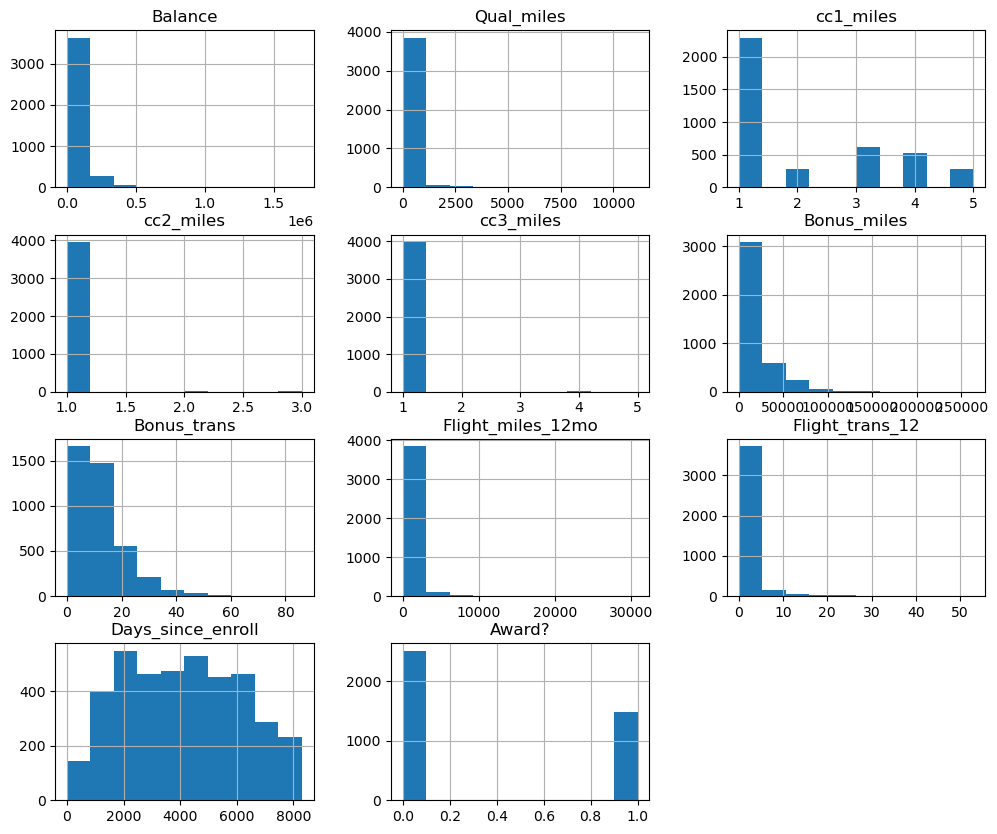

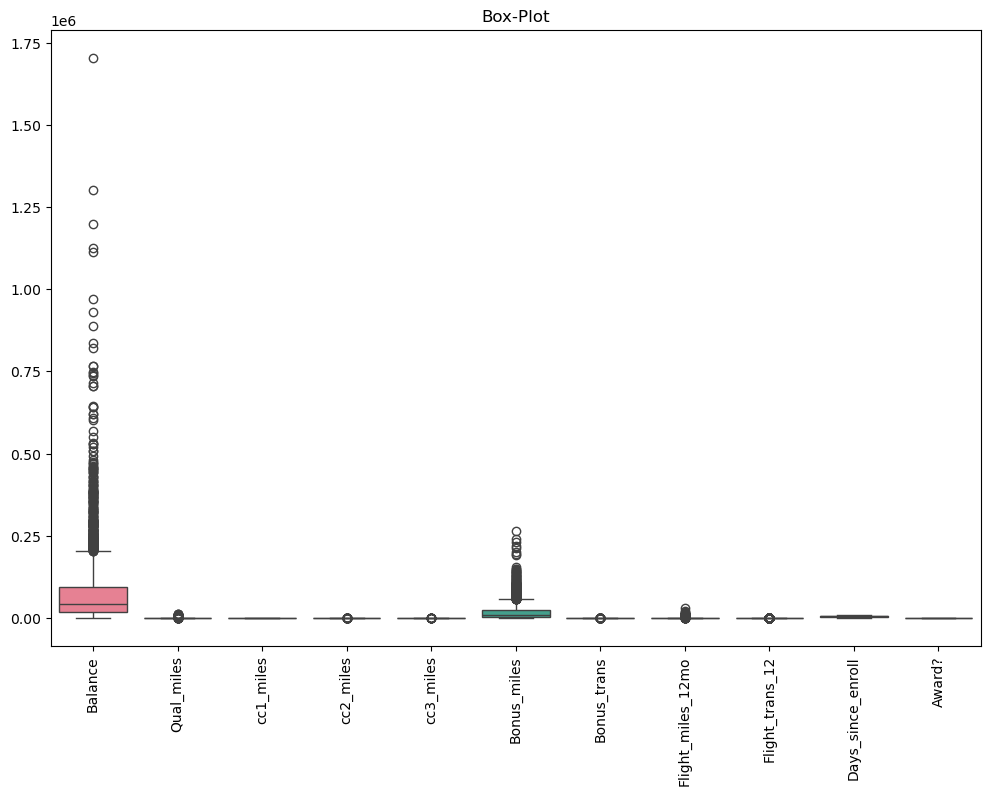

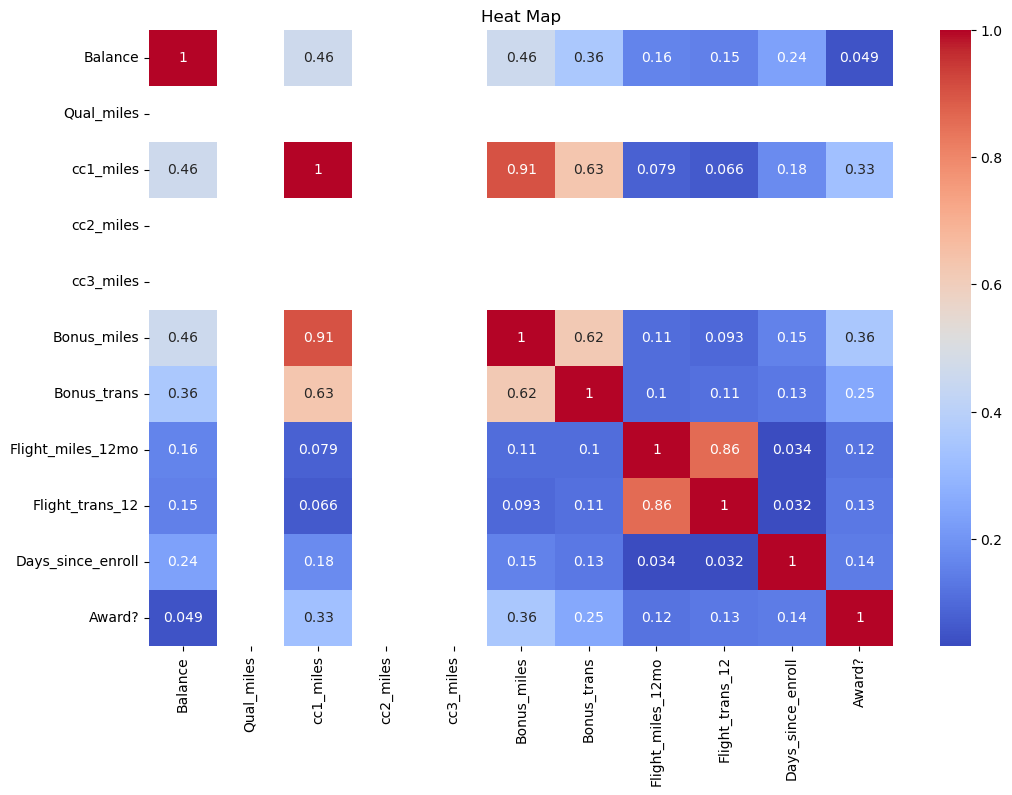

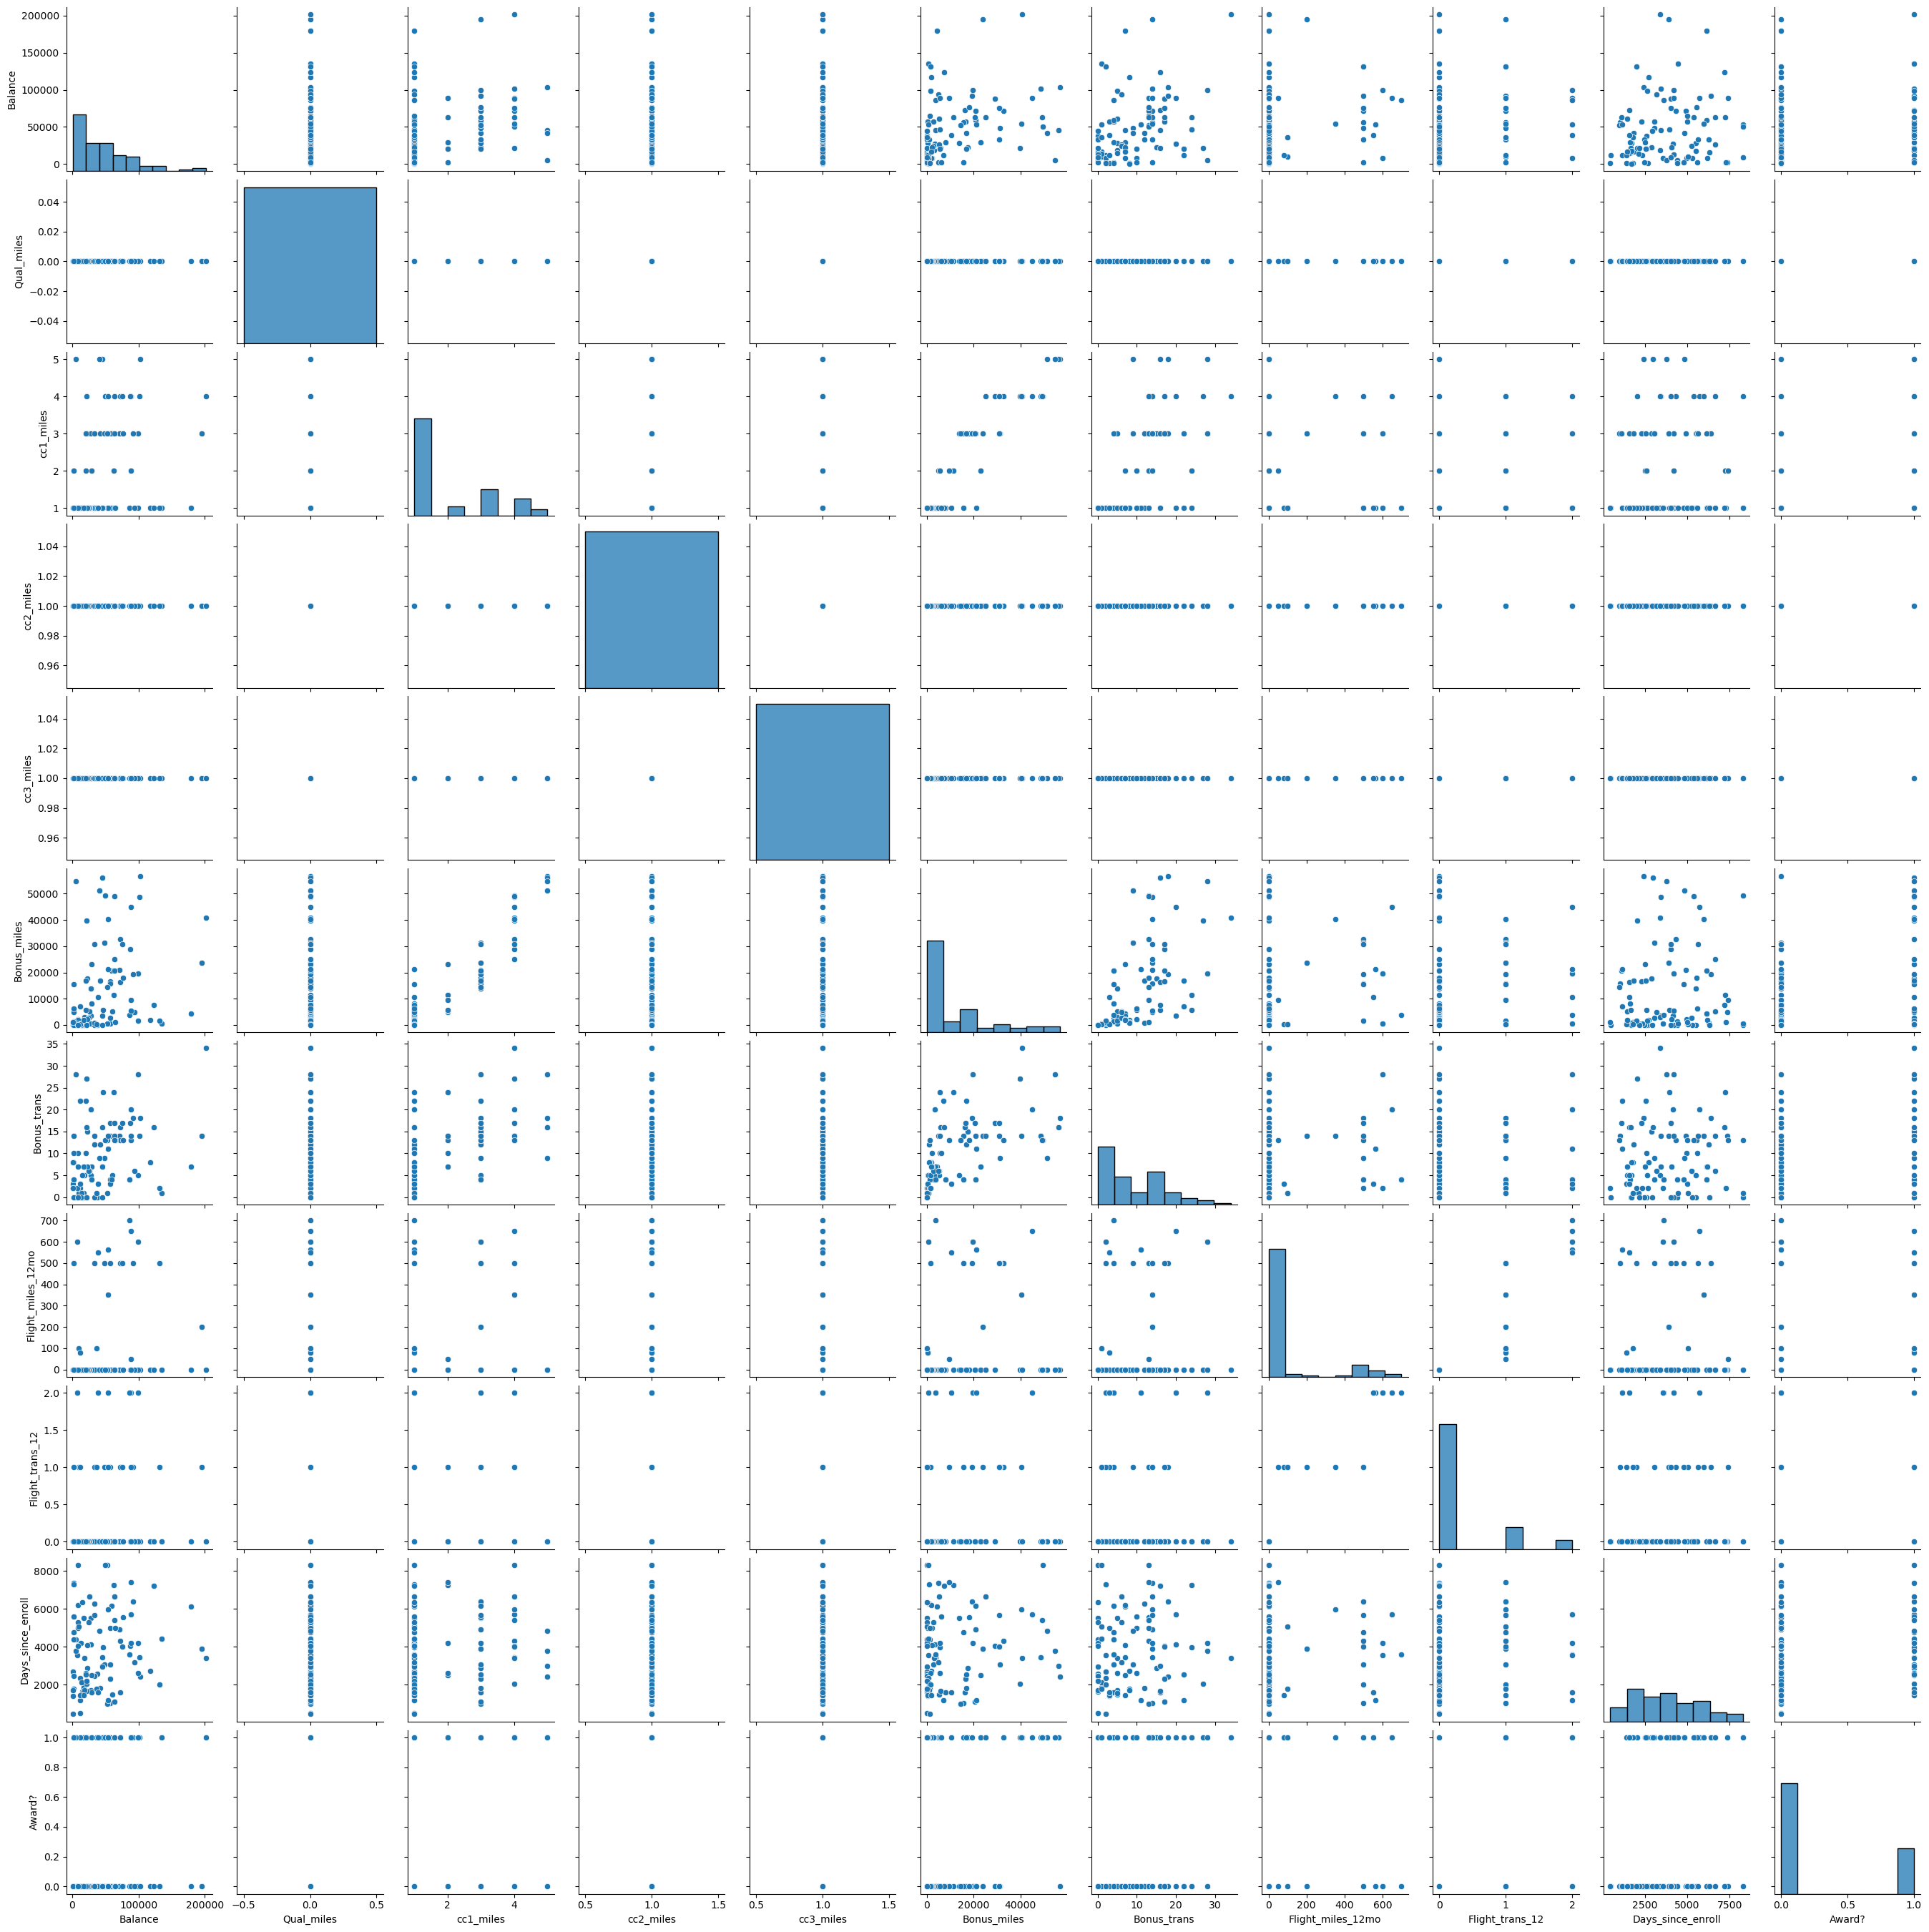

C:\Users\NIKHIL\AppData\Local\Temp\ipykernel_29616\1747406424.py:95: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], label=col)
C:\Users\NIKHIL\AppData\Local\Temp\ipykernel_29616\1747406424.py:95: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], label=col)
C:\Users\NIKHIL\AppData\Local\Temp\ipykernel_29616\1747406424.py:95: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], label=col)


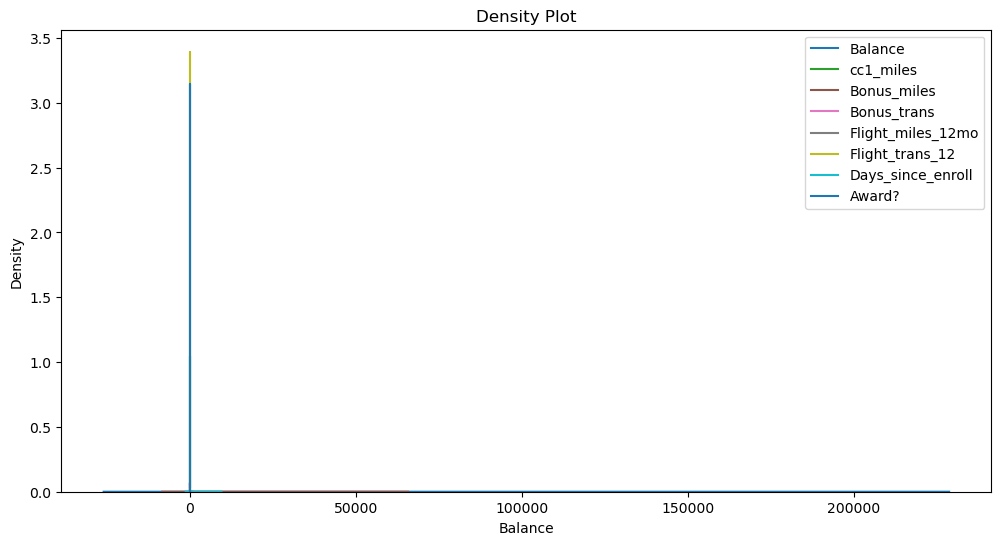

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Win

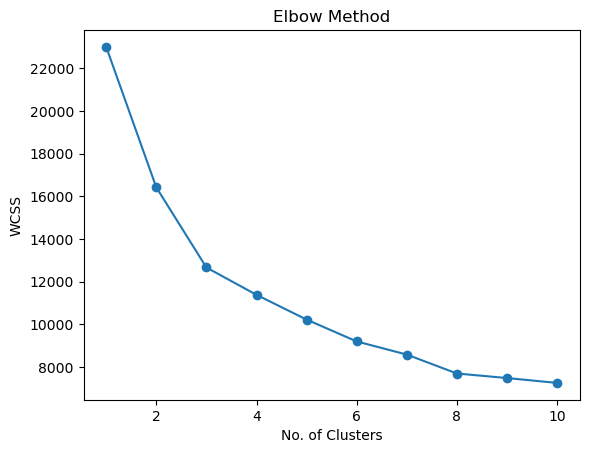

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


KMeans Silhouette Score: 0.22962827467448732


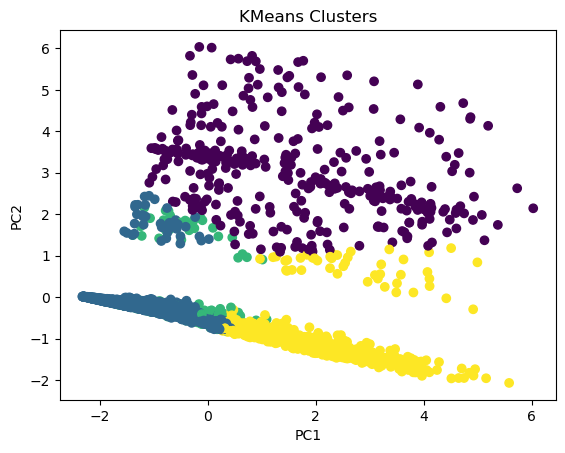

Unique DBSCAN clusters: [-1  0  1  2  3  4  5  6]
DBSCAN Silhouette Score: 0.2673349072078038


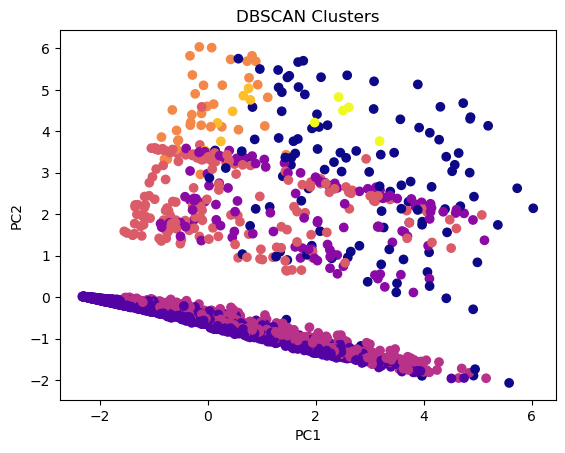


DBSCAN eps=0.5, min_samples=5
Number of Clusters: 19

DBSCAN eps=1.0, min_samples=5
Number of Clusters: 14

DBSCAN eps=1.5, min_samples=10
Number of Clusters: 6

FINAL COMPARISON
KMeans Score : 0.22962827467448732
DBSCAN Score : 0.2673349072078038


In [1]:
import pandas as pd
import numpy as np

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_excel(
    r"C:\Users\NIKHIL\Downloads\data science assignment\data science assignment\EastWestAirlines.xlsx",
    sheet_name="data"
)

# ==========================================
# DATA OVERVIEW
# ==========================================

print(df.info())

print(df.describe())

print(df.head())

print(df.isnull().sum())

# ==========================================
# DROP UNNECESSARY COLUMN
# ==========================================

df = df.drop("ID#", axis=1)

# ==========================================
# MISSING VALUE HANDLING
# ==========================================

df = df.fillna(df.mean(numeric_only=True))

print(df.isnull().sum())

# ==========================================
# VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
df.hist(figsize=(12,10))

plt.show()

# Box Plot
plt.figure(figsize=(12,8))

sns.boxplot(df)

plt.title("Box-Plot")

plt.xticks(rotation=90)

plt.show()

# ==========================================
# OUTLIER HANDLING
# ==========================================

Q1 = df.quantile(0.25)

Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~((df < (Q1 - 1.5 * IQR)) |
      (df > (Q3 + 1.5 * IQR))).any(axis=1)
]

# Heat Map
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Heat Map")

plt.show()

# Pair Plot
sns.pairplot(df.sample(100))

plt.show()

# Density Plot
plt.figure(figsize=(12,6))

for col in df.columns:
    sns.kdeplot(df[col], label=col)

plt.legend()

plt.title("Density Plot")

plt.show()

# ==========================================
# FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

# ==========================================
# KMEANS CLUSTERING
# ==========================================

from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import silhouette_score

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

# Elbow Method
plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("No. of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# ==========================================
# KMEANS MODEL
# ==========================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(scaled_data)

df['KMeans_Cluster'] = kmeans_labels

print(
    "KMeans Silhouette Score:",
    silhouette_score(scaled_data, kmeans_labels)
)

# ==========================================
# PCA VISUALIZATION
# ==========================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=kmeans_labels,
    cmap='viridis'
)

plt.title("KMeans Clusters")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()

# ==========================================
# DBSCAN MODEL
# ==========================================

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(scaled_data)

df['DBSCAN_Cluster'] = db_labels

print(
    "Unique DBSCAN clusters:",
    np.unique(db_labels)
)

mask = db_labels != -1

print(
    "DBSCAN Silhouette Score:",
    silhouette_score(
        scaled_data[mask],
        db_labels[mask]
    )
)

# DBSCAN Visualization
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=db_labels,
    cmap='plasma'
)

plt.title("DBSCAN Clusters")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()

# ==========================================
# MULTIPLE DBSCAN EXPERIMENTS
# ==========================================

params = [
    (0.5, 5),
    (1.0, 5),
    (1.5, 10)
]

for eps, min_samples in params:

    db = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = db.fit_predict(scaled_data)

    print(
        f"\nDBSCAN eps={eps}, min_samples={min_samples}"
    )

    print(
        "Number of Clusters:",
        len(set(labels)) - (1 if -1 in labels else 0)
    )

# ==========================================
# FINAL COMPARISON
# ==========================================

print("\nFINAL COMPARISON")

print(
    "KMeans Score :",
    silhouette_score(
        scaled_data,
        kmeans_labels
    )
)

print(
    "DBSCAN Score :",
    silhouette_score(
        scaled_data[mask],
        db_labels[mask]
    )
)

# Cluster Interpretation

1. K-Means formed clusters based on similarity among airline customers.

2. DBSCAN identified dense customer groups and detected noise points.

3. PCA visualization helped in understanding cluster separation clearly.

4. Different DBSCAN parameter values changed the cluster formation and number of noise points.

5. K-Means performed better for compact clusters while DBSCAN handled irregular cluster structures.

KMeans groups customers into fixed segments
DBSCAN identifies loyal vs irregular customers
DBSCAN detects outliers (important in marketing)
KMeans better for segmentation, DBSCAN better for anomaly detection
